In [9]:
import numpy as np

from cgtools.workflow.data import read_npz
from cgtools.workflow.martini_mappings import bead_mappings_reline, assign_bead_ids
from cgtools.coarse_grain import group_array_by_mol
from cgtools.workflow.plotting import PlotDataHistogram

In [33]:
file = "/home/eshinkle/Projects/coarse-graining/investigative_codes/mixtures/reline_100/processed_data/temp_298dot15_counts_250-250-500_0/processed_data_10th.npz"
file = "/home/eshinkle/Projects/coarse-graining/investigative_codes/mixtures/reline_10000/processed_data/temp_298dot15_counts_250-250-500_cog_0/processed_data_10th.npz"
data = read_npz(file, "")

Loading data from /home/eshinkle/Projects/coarse-graining/investigative_codes/mixtures/reline_10000/processed_data/temp_298dot15_counts_250-250-500_cog_0/processed_data_10th.npz


In [30]:
import os
import json
import itertools as it
import time
import math
import numpy as np
import torch
from cgtools.workflow.martini_mappings import bead_mappings_reline, assign_bead_ids
from cgtools.rdf import calculate_rdf as imported_calculate_rdf
from cgtools.rdf import calculate_adf as imported_calculate_adf
from cgtools.physics import calc_kE_from_vel, calc_temp_from_kE, calc_temp_from_vel, wrap_coordinates
from cgtools.workflow.readers import LammpsOutputReader, GromacsOutputReader
from cgtools.workflow.writers import extxyz_writer
from cgtools.workflow.units import data_units_dict
from cgtools.coarse_grain import (
    group_array_by_mol,
)
from hippynn.cgtools.coarse_grain import coarse_grain_all, cg_one_center_of_mass_pbc, cg_one_center_of_geometry_pbc, cg_one_mass_weighted_average, cg_one_average, cg_one_sum
from cgtools.pbc import unwrap_traj

In [32]:
data.data["aa_unwrapped_position"]

array([[[12.89000034, 14.45000052, 17.51000047],
        [13.19000006, 15.26000023, 16.8599999 ],
        [13.28999996, 13.56999993, 17.02999949],
        ...,
        [23.6500001 ,  2.18999997, 41.36000156],
        [23.97000074,  5.6099999 , 42.57999897],
        [24.17000055,  5.13000011, 44.14999962]],

       [[12.16717839, 14.73550916, 17.62592435],
        [12.37999082, 15.71060538, 17.21194506],
        [12.8927362 , 14.03617501, 17.23608136],
        ...,
        [24.01196718,  2.62007922, 41.34799957],
        [24.11606312,  5.75091839, 43.0635643 ],
        [24.54483747,  5.0008136 , 44.52830791]],

       [[12.08957195, 14.90440965, 17.54592061],
        [12.15646267, 15.87632775, 17.07860827],
        [12.97600031, 14.35263753, 17.26794362],
        ...,
        [23.41995716,  2.09942147, 41.97331429],
        [23.14604521,  5.40309429, 42.97447681],
        [23.77431393,  5.18231034, 44.56958771]],

       ...,

       [[11.82728767, 14.6310389 , 18.60078096],
        [11

In [34]:
bead_ids = data.data["mol_ids"]
bead_types = None
mass_map = cg_one_sum
mass_kwargs = {}
wrapped_position_map = cg_one_center_of_geometry_pbc
wrapped_position_kwargs = {"cells": data.data["cells"]}
unwrapped_position_map = cg_one_average
unwrapped_position_kwargs = {}
velocity_map = cg_one_average
velocity_kwargs = {}
force_map = cg_one_sum
force_kwargs = {}


if data.data["aa_unwrapped_position"].shape == (0,):
    data.data["position"] = coarse_grain_all(
        values = data.data["aa_position"], 
        atom_to_bead = bead_ids, 
        coarse_grain_one = wrapped_position_map, 
        **wrapped_position_kwargs
    )
# positions are unwrapped
else:
    data.data["unwrapped_position"] = coarse_grain_all(
        values = data.data["aa_unwrapped_position"], 
        atom_to_bead = bead_ids, 
        coarse_grain_one = unwrapped_position_map, 
        **unwrapped_position_kwargs
    )
    
(data.data["position"] == wrap_coordinates(data.data["unwrapped_position"], data.data["cells"])[0]).all()

False

In [41]:
from_wrapped = coarse_grain_all(
        values = data.data["aa_position"], 
        atom_to_bead = bead_ids, 
        coarse_grain_one = wrapped_position_map, 
        **wrapped_position_kwargs
    )

In [45]:
(from_wrapped - old_pos).min()

-7.6293945e-06

In [35]:
new_pos = wrap_coordinates(data.data["unwrapped_position"], data.data["cells"])[0]

In [36]:
old_pos = data.data["position"]

In [40]:
(new_pos-old_pos).max()

42.704764107961005

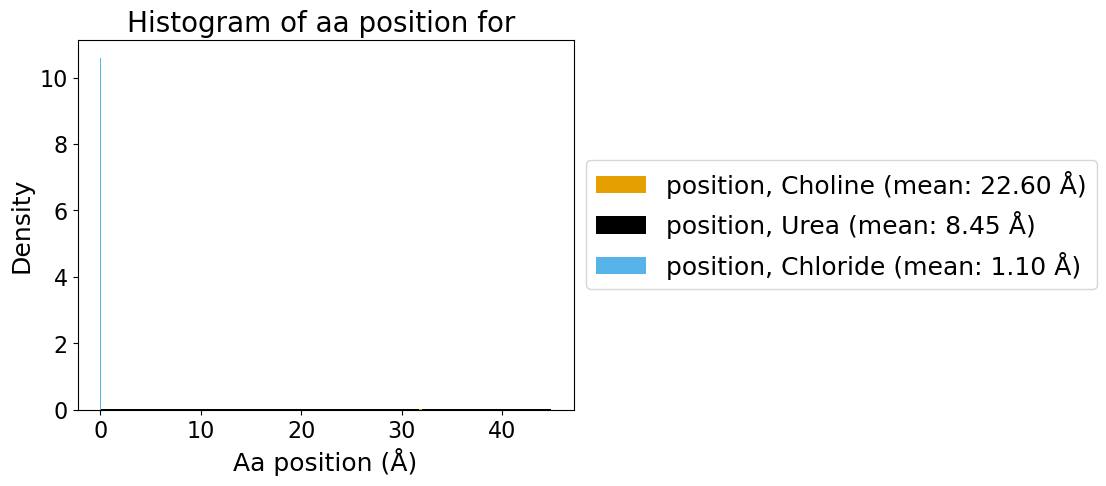

In [23]:
PlotDataHistogram(
    datasets=(data,),
    keys=("aa_position"),
    key_names=("position"),
    transform=None,
    show_mean=True,
    split_types=True,
)

In [3]:
data.data["types"].shape

(1001, 1000)

In [4]:
print(data.data.keys())

dict_keys(['cells', 'aa_position', 'aa_velocity', 'aa_force', 'aa_temperature', 'aa_potential_energy', 'aa_kinetic_energy', 'aa_total_energy', 'aa_types', 'aa_masses', 'record_every', 'dt', 'units_style', 'mol_ids', 'n_mols', 'n_atoms', 'n_frames', 'cell_volumes', 'system_pressure', 'atom_list_to_mol_name', 'aa_unwrapped_position', 'masses', 'position', 'velocity', 'force', 'types', 'type_to_atom_list', 'type_to_mol_name', 'record_interval', 'kinetic_energy', 'rdf_bins', 'rdf_values', 'rdf_values_1_1', 'rdf_values_1_2', 'rdf_values_1_3', 'rdf_values_2_2', 'rdf_values_2_3', 'rdf_values_3_3'])


In [8]:
np.histogram(data.data["position"])

(array([295058, 306372, 296641, 302209, 298414, 297184, 303921, 291810,
        299739, 311652]),
 array([7.6293938e-05, 4.4840670e+00, 8.9680576e+00, 1.3452047e+01,
        1.7936039e+01, 2.2420029e+01, 2.6904018e+01, 3.1388010e+01,
        3.5872002e+01, 4.0355991e+01, 4.4839981e+01], dtype=float32))

In [5]:
del data.data["masses"], data.data["velocity"], data.data["force"], data.data["types"], data.data["type_to_atom_list"], data.data["type_to_mol_name"], data.data["unwrapped_position"], data.data["position"], data.data["msd"]

In [11]:
bead_ids, bead_names = assign_bead_ids(data.data["mol_ids"], data.data["aa_types"], bead_mappings_reline)

bead_names_unique, data.data["types"] = np.unique(bead_names,  return_inverse=True)
data.data["types"] = data.data["types"] + 1 # need to add 1 so we don't have type 0, which is reserved in hippynn
data.data["type_to_mol_name"] = {i+1: name for i, name in enumerate(bead_names_unique)}
# for i, atom_list in enumerate(atom_lists):
#     data.data["type_to_atom_list"][i+1] = "-".join(sorted([str(int(atom_id)) for atom_id in atom_list if atom_id != 0]))
# if "atom_list_to_mol_name" in data.data.keys():
#     data.data["type_to_mol_name"] = dict()
#     for tipe, alist in data.data["type_to_atom_list"].items():
#         data.data["type_to_mol_name"][tipe] = data.data["atom_list_to_mol_name"][alist]

In [12]:
data.data["type_to_mol_name"]

{1: 'Ch1', 2: 'Ch2', 3: 'Cl', 4: 'Urea'}

In [6]:
data.coarse_grain("martini-reline")

Coarse-graining data. This can be a slow step.
Coarse-graining complete.


In [8]:
data.process()

In [9]:
data.calculate_additional_quantities()

In [10]:
data.calculate_rdf()

Calculating RDF


100%|██████████| 11/11 [00:01<00:00,  5.94it/s]


In [7]:
data.data["position"].max()

44.18972794338449

In [8]:
data.data["types"]

array([1, 2, 1, ..., 4, 4, 4])

In [9]:
data.data["type_to_mol_name"]

{1: 'Ch1', 2: 'Ch2', 3: 'Cl', 4: 'Urea'}

In [9]:
data.data["unwrapped_position"].max()

44.865122670307755

In [12]:
data.data["types"]

array([[1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       ...,
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2]])

In [10]:
data.data["cells"]

array([[[44.190002,  0.      ,  0.      ],
        [ 0.      , 44.190002,  0.      ],
        [ 0.      ,  0.      , 44.190002]],

       [[44.190002,  0.      ,  0.      ],
        [ 0.      , 44.190002,  0.      ],
        [ 0.      ,  0.      , 44.190002]],

       [[44.190002,  0.      ,  0.      ],
        [ 0.      , 44.190002,  0.      ],
        [ 0.      ,  0.      , 44.190002]],

       [[44.190002,  0.      ,  0.      ],
        [ 0.      , 44.190002,  0.      ],
        [ 0.      ,  0.      , 44.190002]],

       [[44.190002,  0.      ,  0.      ],
        [ 0.      , 44.190002,  0.      ],
        [ 0.      ,  0.      , 44.190002]],

       [[44.190002,  0.      ,  0.      ],
        [ 0.      , 44.190002,  0.      ],
        [ 0.      ,  0.      , 44.190002]],

       [[44.190002,  0.      ,  0.      ],
        [ 0.      , 44.190002,  0.      ],
        [ 0.      ,  0.      , 44.190002]],

       [[44.190002,  0.      ,  0.      ],
        [ 0.      , 44.190002,  0.      

In [6]:
data.data["mol_ids"]

array([[  0,   0,   0, ..., 999, 999, 999],
       [  0,   0,   0, ..., 999, 999, 999],
       [  0,   0,   0, ..., 999, 999, 999],
       ...,
       [  0,   0,   0, ..., 999, 999, 999],
       [  0,   0,   0, ..., 999, 999, 999],
       [  0,   0,   0, ..., 999, 999, 999]])

In [7]:
data.data["aa_types"]

array([[6, 1, 1, ..., 1, 1, 1],
       [6, 1, 1, ..., 1, 1, 1],
       [6, 1, 1, ..., 1, 1, 1],
       ...,
       [6, 1, 1, ..., 1, 1, 1],
       [6, 1, 1, ..., 1, 1, 1],
       [6, 1, 1, ..., 1, 1, 1]])

In [3]:
pos = data.data["aa_position"]
mol_id = data.data["mol_ids"]
typ = data.data["aa_types"]

In [39]:
bead_ids

array([   0,    0,    0, ..., 2249, 2249, 2249])

In [8]:
assign_bead_ids(mol_id, typ, pattern_map)

NameError: name 'pattern_map' is not defined

In [4]:
from cgtools.workflow.martini_mappings import bead_mappings_reline, assign_bead_ids

In [5]:
bead_ids = assign_bead_ids(mol_id, typ, bead_mappings_reline)

In [6]:
from hippynn.cgtools.coarse_grain import cg_one_sum, coarse_grain_all

In [8]:
coarse_grain_all(data.data["aa_masses"], bead_ids, cg_one_sum, masses=None, cells=None, atom_species=None, bead_species=None, single_frame=False)

array([[[45.060725],
        [59.110583],
        [45.060725],
        ...,
        [ 4.031788],
        [56.02365 ],
        [ 4.031788]],

       [[45.060725],
        [59.110583],
        [45.060725],
        ...,
        [ 4.031788],
        [56.02365 ],
        [ 4.031788]],

       [[45.060725],
        [59.110583],
        [45.060725],
        ...,
        [ 4.031788],
        [56.02365 ],
        [ 4.031788]],

       ...,

       [[45.060725],
        [59.110583],
        [45.060725],
        ...,
        [ 4.031788],
        [56.02365 ],
        [ 4.031788]],

       [[45.060725],
        [59.110583],
        [45.060725],
        ...,
        [ 4.031788],
        [56.02365 ],
        [ 4.031788]],

       [[45.060725],
        [59.110583],
        [45.060725],
        ...,
        [ 4.031788],
        [56.02365 ],
        [ 4.031788]]])